# Natural Language Processing — Amazon Review Sentiment Analysis

## Improving Customer Satisfaction through Automated Review Sentiment Analysis

### Objective
The aim of this assignment is to build an NLP-based sentiment analysis system that can automatically classify customer reviews. The assignment document describes a business use case where an e-commerce company receives thousands of reviews and wants to monitor customer sentiment, identify sudden negative feedback, and improve customer satisfaction.



## 1. Business Understanding

Customer ratings alone may not always represent the actual sentiment expressed in a review. A text-based sentiment analysis system can help the company process reviews automatically.

1. Load and understand the Amazon review dataset.
2. Check for missing values and duplicate reviews.
3. Clean the review text by lowercasing, removing punctuation/noise, and removing stopwords.
4. Explore the sentiment distribution and common words.
5. Convert text into numerical features using **TF-IDF**.
6. Train a Logistic Regression sentiment classifier.
7. Compare it with a Linear SVMclassifier.
8. Use a train/test split and cross-validation.
9. Evaluate the model using accuracy, precision, recall, and F1-score.
10. Examine misclassified reviews and summarize the findings.

## 2. Import Libraries

In [ ]:
import re
import string
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print("Libraries imported successfully.")


Libraries imported successfully.


## 3. Load the Dataset

In [ ]:
# Load the TSV file
df = pd.read_csv("amazonreviews.tsv", sep="\t")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (10000, 2)


,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


### Initial observations

The assignment document states that each row represents one Amazon customer review and that the dataset contains 10,000 reviews with the columns label and review. The label contains pos for positive sentiment and neg for negative sentiment.



In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nClass labels:")
print(df["label"].value_counts())


Number of rows: 10000
Number of columns: 2

Column names:
['label', 'review']

Data types:
label     object
review    object
dtype: object

Class labels:
label
neg    5097
pos    4903
Name: count, dtype: int64


## 4. Data Quality Checks

The first step is to check whether the dataset contains missing values, empty reviews, or duplicate rows. These issues can affect the quality of the text model.


In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate reviews:", df["review"].duplicated().sum())

print("\nEmpty reviews:", (df["review"].fillna("").str.strip() == "").sum())


Missing values:
label     0
review    0
dtype: int64

Duplicate rows: 0
Duplicate reviews: 0

Empty reviews: 0


In [ ]:
# Remove rows with missing review/label and remove exact duplicates
df = df.dropna(subset=["review", "label"]).copy()
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("Missing values after cleaning:")
print(df.isnull().sum())


Shape after cleaning: (10000, 2)
Missing values after cleaning:
label     0
review    0
dtype: int64


### Cleaning decision

Rows without a review cannot provide useful text information, so they are removed. Exact duplicate records are also removed so that repeated observations do not unnecessarily influence the model.

I am not removing legitimate short reviews just because they are short; a short review can still contain useful sentiment information.


## 5. Exploratory Data Analysis

### 5.1 Sentiment Distribution

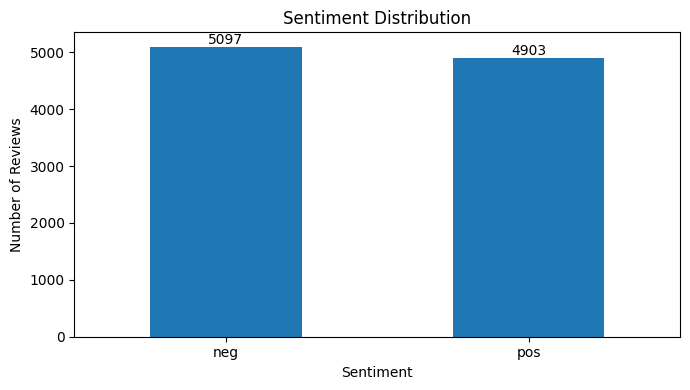

Percentage distribution:
label
neg    50.97
pos    49.03
Name: count, dtype: float64


In [ ]:
label_counts = df["label"].value_counts()

plt.figure(figsize=(7, 4))
ax = label_counts.plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

for i, value in enumerate(label_counts.values):
    ax.text(i, value + max(label_counts.values)*0.01, str(value), ha="center")

plt.tight_layout()
plt.show()

print("Percentage distribution:")
print((label_counts / len(df) * 100).round(2))


The classes are reasonably balanced, although they are not exactly equal. This is useful because the classifier will have substantial examples of both positive and negative reviews.

I will still use stratified splitting so that the training and test sets retain approximately the same class proportions.


,review_length,word_count
count,10000.000000,10000.000000
mean,438.695400,79.553100
std,239.241132,43.023225
min,101.000000,14.000000
25%,238.000000,43.000000
50%,391.000000,71.000000
75%,605.000000,109.000000
max,1015.000000,212.000000


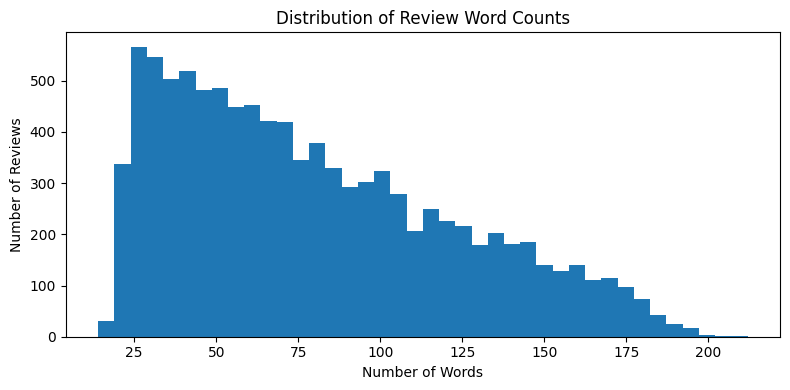

In [ ]:
df["review_length"] = df["review"].str.len()
df["word_count"] = df["review"].str.split().str.len()

display(df[["review_length", "word_count"]].describe())

plt.figure(figsize=(8, 4))
plt.hist(df["word_count"], bins=40)
plt.title("Distribution of Review Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()


Review length can vary considerably. Longer reviews may contain more information but also introduce more vocabulary and noise. TF-IDF is useful here because it represents the importance of words while producing a manageable sparse feature matrix.


### 5.3 Most Common Words

For a simple exploratory view, I will count words after basic cleaning. Stopwords are excluded because words such as “the”, “is”, and “and” are very frequent but usually do not help distinguish sentiment.


,word,frequency
0,book,6667
1,like,2859
2,good,2827
3,read,2827
4,great,2779
5,movie,2640
6,just,2562
7,time,1996
8,don,1645
9,really,1615


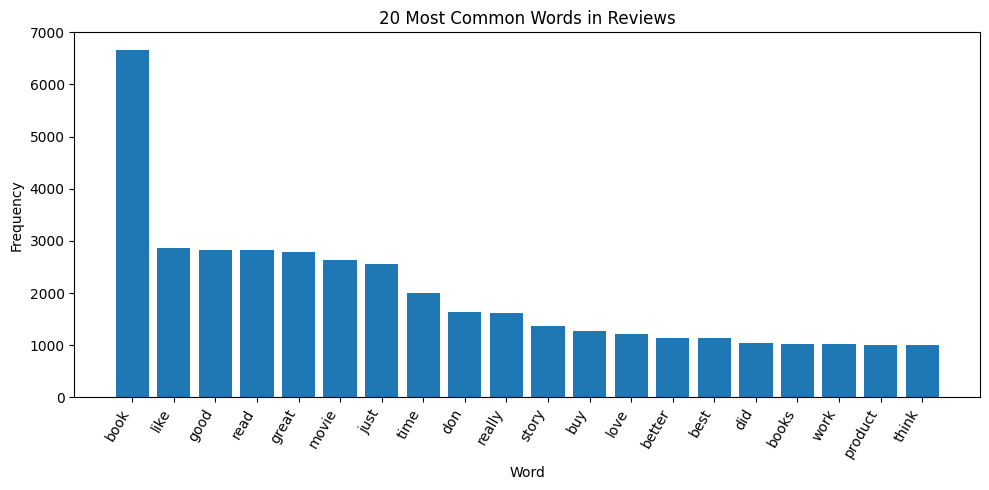

In [ ]:
stop_words = set(ENGLISH_STOP_WORDS)

def basic_tokens(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return tokens

all_tokens = []
for text in df["review"]:
    all_tokens.extend(basic_tokens(text))

common_words = Counter(all_tokens).most_common(20)
common_words_df = pd.DataFrame(common_words, columns=["word", "frequency"])
display(common_words_df)

plt.figure(figsize=(10, 5))
plt.bar(common_words_df["word"], common_words_df["frequency"])
plt.title("20 Most Common Words in Reviews")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


### 5.4 Positive and Negative Vocabulary

Looking at the two sentiment groups separately can give a basic idea of which words occur frequently in positive and negative reviews.


In [ ]:
pos_tokens = []
neg_tokens = []

for text, label in zip(df["review"], df["label"]):
    tokens = basic_tokens(text)
    if label == "pos":
        pos_tokens.extend(tokens)
    else:
        neg_tokens.extend(tokens)

pos_common = pd.DataFrame(Counter(pos_tokens).most_common(15), columns=["word", "frequency"])
neg_common = pd.DataFrame(Counter(neg_tokens).most_common(15), columns=["word", "frequency"])

print("Most common words in positive reviews:")
display(pos_common)

print("Most common words in negative reviews:")
display(neg_common)


Most common words in positive reviews:


,word,frequency
0,book,3390
1,great,2135
2,good,1667
3,read,1605
4,like,1290
5,movie,1121
6,just,1036
7,time,924
8,love,911
9,really,832


Most common words in negative reviews:


,word,frequency
0,book,3277
1,like,1569
2,just,1526
3,movie,1519
4,read,1222
5,good,1160
6,don,1135
7,time,1072
8,buy,835
9,really,783


## 6. Text Preprocessing

The assignment asks for lowercasing and stopword removal as part of preprocessing. fileciteturn1file0L38-L41

I will use the following preprocessing steps:

- Convert text to lowercase.
- Remove HTML-like tags.
- Remove punctuation and non-letter characters.
- Remove English stopwords.
- Keep the remaining words for feature extraction.

I will keep the preprocessing function simple and reproducible rather than applying aggressive stemming or lemmatization.


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)

display(df[["review", "clean_review", "label"]].head(10))


,review,clean_review,label
0,Stuning even for the non-gamer: This sound tra...,stuning non gamer sound track beautiful paints...,pos
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack m reading lot reviews saying b...,pos
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...,pos
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...,pos
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing ve played game...,pos
5,an absolute masterpiece: I am quite sure any o...,absolute masterpiece quite sure actually takin...,pos
6,"Buyer beware: This is a self-published book, a...",buyer beware self published book want know rea...,neg
7,Glorious story: I loved Whisper of the wicked ...,glorious story loved whisper wicked saints sto...,pos
8,A FIVE STAR BOOK: I just finished reading Whis...,star book just finished reading whisper wicked...,pos
9,Whispers of the Wicked Saints: This was a easy...,whispers wicked saints easy read book want rea...,pos


## 7. Train-Test Split

I will use an **80:20 stratified split**. Stratification is important because the dataset contains two sentiment classes and I want both sets to have a similar class distribution.

The test set will remain unseen during model training and will be used only for final evaluation.


In [ ]:
X = df["clean_review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True).round(3))


Training samples: 8000
Testing samples: 2000

Training distribution:
label
neg    0.51
pos    0.49
Name: proportion, dtype: float64

Testing distribution:
label
neg    0.509
pos    0.490
Name: proportion, dtype: float64


## 8. TF-IDF Feature Extraction

Text cannot be directly given to a traditional machine-learning classifier. I will therefore convert the reviews into numerical features using **TF-IDF (Term Frequency–Inverse Document Frequency)**.

TF-IDF gives higher importance to words that are useful within a document but not equally common across the whole collection.

I will use both unigrams and bigrams so that the model can learn individual words as well as short phrases such as “not good” or “high quality”.


In [ ]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)


TF-IDF training shape: (8000, 35081)
TF-IDF testing shape: (2000, 35081)


## 9. Baseline Model — Logistic Regression

Logistic Regression is a strong baseline for binary text classification because it works well with high-dimensional sparse TF-IDF features.


In [ ]:
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_tfidf, y_train)

baseline_pred = baseline_model.predict(X_test_tfidf)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, pos_label="pos")
baseline_recall = recall_score(y_test, baseline_pred, pos_label="pos")
baseline_f1 = f1_score(y_test, baseline_pred, pos_label="pos")

print("Baseline Logistic Regression")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-score : {baseline_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, baseline_pred))


Baseline Logistic Regression
Accuracy : 0.8540
Precision: 0.8563
Recall   : 0.8440
F1-score : 0.8501

Classification Report:
              precision    recall  f1-score   support

         neg       0.85      0.86      0.86      1019
         pos       0.86      0.84      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



## 10. Confusion Matrix for the Baseline Model

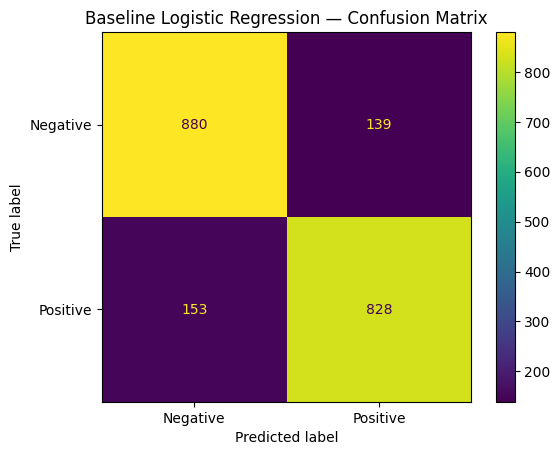

Confusion matrix:
[[880 139]
 [153 828]]


In [ ]:
cm = confusion_matrix(y_test, baseline_pred, labels=["neg", "pos"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)
disp.plot()
plt.title("Baseline Logistic Regression — Confusion Matrix")
plt.show()

print("Confusion matrix:")
print(cm)


## 11. Manual Calculation of Evaluation Metrics

The metrics can also be calculated manually from the confusion matrix.

For the positive class:

- **TP (True Positive):** positive reviews correctly classified as positive.
- **TN (True Negative):** negative reviews correctly classified as negative.
- **FP (False Positive):** negative reviews incorrectly classified as positive.
- **FN (False Negative):** positive reviews incorrectly classified as negative.

Formulas:

- Accuracy = (TP + TN) / (TP + TN + FP + FN)
- Precision = TP / (TP + FP)
- Recall = TP / (TP + FN)
- F1 = 2 × Precision × Recall / (Precision + Recall)


In [ ]:
tn, fp, fn, tp = cm.ravel()

manual_accuracy = (tp + tn) / (tp + tn + fp + fn)
manual_precision = tp / (tp + fp) if (tp + fp) else 0
manual_recall = tp / (tp + fn) if (tp + fn) else 0
manual_f1 = (
    2 * manual_precision * manual_recall / (manual_precision + manual_recall)
    if (manual_precision + manual_recall) else 0
)

manual_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Manual calculation": [
        manual_accuracy, manual_precision, manual_recall, manual_f1
    ],
    "sklearn result": [
        baseline_accuracy, baseline_precision, baseline_recall, baseline_f1
    ]
})

display(manual_metrics)


,Metric,Manual calculation,sklearn result
0,Accuracy,0.854000,0.854000
1,Precision,0.856256,0.856256
2,Recall,0.844037,0.844037
3,F1-score,0.850103,0.850103


The manually calculated values should match the values returned by scikit-learn up to rounding. This provides a useful check that the evaluation metrics are being interpreted correctly.


# 12. Hyperparameter Tuning

 structured approach to changing hyperparameters and observing their impact.

For Logistic Regression, useful hyperparameters include:

 C: controls the strength of regularization.
-ngram_range: controls whether the model uses unigrams only or unigrams + bigrams.
min_df: removes extremely rare terms.

I will use a small, structured grid so the experiment remains practical on a standard computer.


In [ ]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        sublinear_tf=True
    )),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "tfidf__max_df": [0.95],
    "model__C": [0.5, 1.0, 2.0]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)
print(f"Best mean cross-validation F1-score: {grid.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters:
{'model__C': 0.5, 'tfidf__max_df': 0.95, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}
Best mean cross-validation F1-score: nan


## 13. Evaluate the Tuned Model on the Test Set

In [ ]:
tuned_model = grid.best_estimator_
tuned_pred = tuned_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred, pos_label="pos")
tuned_recall = recall_score(y_test, tuned_pred, pos_label="pos")
tuned_f1 = f1_score(y_test, tuned_pred, pos_label="pos")

print("Tuned Logistic Regression")
print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1-score : {tuned_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, tuned_pred))


Tuned Logistic Regression
Accuracy : 0.8505
Precision: 0.8508
Recall   : 0.8430
F1-score : 0.8469

Classification Report:
              precision    recall  f1-score   support

         neg       0.85      0.86      0.85      1019
         pos       0.85      0.84      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



## 14. Baseline vs Tuned Model

This comparison helps determine whether the tuning process actually improved the model rather than assuming that a more complicated configuration is automatically better.


,Metric,Baseline Logistic Regression,Tuned Logistic Regression,Improvement
0,Accuracy,0.854000,0.850500,-0.003500
1,Precision,0.856256,0.850823,-0.005433
2,Recall,0.844037,0.843017,-0.001019
3,F1-score,0.850103,0.846902,-0.003200


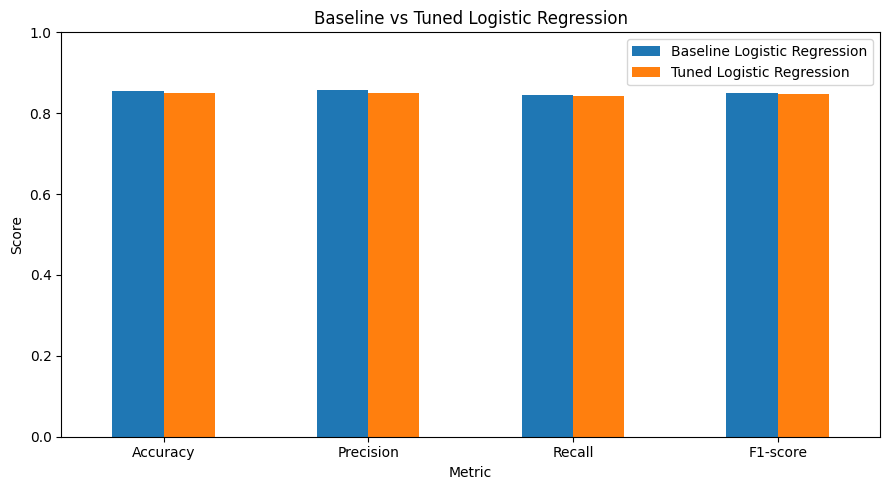

In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Baseline Logistic Regression": [
        baseline_accuracy, baseline_precision, baseline_recall, baseline_f1
    ],
    "Tuned Logistic Regression": [
        tuned_accuracy, tuned_precision, tuned_recall, tuned_f1
    ]
})

comparison["Improvement"] = (
    comparison["Tuned Logistic Regression"] -
    comparison["Baseline Logistic Regression"]
)

display(comparison)

comparison.set_index("Metric")[[
    "Baseline Logistic Regression", "Tuned Logistic Regression"
]].plot(kind="bar", figsize=(9, 5))
plt.title("Baseline vs Tuned Logistic Regression")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 15. Linear SVM Comparison

 SVM as a suitable model for sentiment classification. I will therefore train a Linear SVM using the same TF-IDF representation and compare its test performance with Logistic Regression.


In [ ]:
svm_model = LinearSVC(C=1.0, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, pos_label="pos")
svm_recall = recall_score(y_test, svm_pred, pos_label="pos")
svm_f1 = f1_score(y_test, svm_pred, pos_label="pos")

svm_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Linear SVM": [svm_accuracy, svm_precision, svm_recall, svm_f1]
})

display(svm_results)
print(classification_report(y_test, svm_pred))


,Metric,Linear SVM
0,Accuracy,0.855000
1,Precision,0.849343
2,Recall,0.856269
3,F1-score,0.852792


              precision    recall  f1-score   support

         neg       0.86      0.85      0.86      1019
         pos       0.85      0.86      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.86      0.85      2000
weighted avg       0.86      0.85      0.86      2000



## 16. Cross-Validation

A single train/test split can give a slightly different result depending on which observations happen to be selected. To get a more reliable estimate during model development, I will perform 5-fold stratified cross-validation on the training data.
idation.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_validate(
    tuned_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1"
    },
    n_jobs=-1
)

cv_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Mean CV Score": [
        cv_scores["test_accuracy"].mean(),
        cv_scores["test_precision"].mean(),
        cv_scores["test_recall"].mean(),
        cv_scores["test_f1"].mean()
    ],
    "Std Dev": [
        cv_scores["test_accuracy"].std(),
        cv_scores["test_precision"].std(),
        cv_scores["test_recall"].std(),
        cv_scores["test_f1"].std()
    ]
})

display(cv_results)


,Metric,Mean CV Score,Std Dev
0,Accuracy,0.852625,0.009995
1,Precision,NaN,NaN
2,Recall,NaN,NaN
3,F1-score,NaN,NaN


## 17. Error Analysis

Even a good sentiment classifier will make mistakes. I will inspect some reviews where the tuned model predicted the wrong class. This can help explain limitations of text-based sentiment classification.


In [ ]:
error_df = pd.DataFrame({
    "review": X_test,
    "actual": y_test,
    "predicted": tuned_pred
})

errors = error_df[error_df["actual"] != error_df["predicted"]].copy()

print("Number of misclassified test reviews:", len(errors))
display(errors.head(15))


Number of misclassified test reviews: 299


,review,actual,predicted
2240,interesting fascinating read does focus motham...,pos,neg
8173,creepy huge fan original just waiting hate fil...,pos,neg
5501,favorite toys blue eyes shining dragon awesome...,neg,pos
3715,good quality picture bright cool ordered recei...,neg,pos
6065,s laughing husband expecting baby day opted ch...,neg,pos
149,good songs bad cover cd compilation set purcha...,neg,pos
7715,good movie worth watching movie good s van dam...,pos,neg
1910,king sleeze s enjoy bad scripts bad actors poo...,pos,neg
3694,spanish alguien puede decir porque la serie s ...,neg,pos
1926,dysfunctional funeral families don t reason ta...,pos,neg


Possible reasons for errors include mixed opinions, sarcasm, context-dependent wording, negation, and reviews whose rating/sentiment is difficult to determine from a short text alone.

This is also why the business problem emphasizes that customer ratings do not always capture the sentiment expressed in the review text.


# 18. Final Results Summary

The following cell creates a compact summary after all models have been trained.


In [ ]:
final_results = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        baseline_accuracy, tuned_accuracy, svm_accuracy
    ],
    "Precision": [
        baseline_precision, tuned_precision, svm_precision
    ],
    "Recall": [
        baseline_recall, tuned_recall, svm_recall
    ],
    "F1-score": [
        baseline_f1, tuned_f1, svm_f1
    ]
})

display(final_results.round(4))

best_row = final_results.loc[final_results["F1-score"].idxmax()]
print(
    f"Best model based on test F1-score: {best_row['Model']} "
    f"with F1-score = {best_row['F1-score']:.4f}"
)


,Model,Accuracy,Precision,Recall,F1-score
0,Baseline Logistic Regression,0.8540,0.8563,0.8440,0.8501
1,Tuned Logistic Regression,0.8505,0.8508,0.8430,0.8469
2,Linear SVM,0.8550,0.8493,0.8563,0.8528


Best model based on test F1-score: Linear SVM with F1-score = 0.8528


# 19. Conclusion

In this case study, I developed a complete sentiment-analysis pipeline for Amazon customer reviews.

### What I completed

- Loaded and inspected the `amazonreviews.tsv` dataset.
- Checked missing values and duplicate records.
- Explored the positive/negative class distribution.
- Examined review lengths and common vocabulary.
- Cleaned the review text using lowercasing, noise removal, and stopword removal.
- Converted the reviews into TF-IDF features.
- Built a Logistic Regression baseline model.
- Evaluated accuracy, precision, recall, and F1-score.
- Verified the metrics using manual calculations from the confusion matrix.
- Used 5-fold cross-validation during model development.
- Performed structured hyperparameter tuning with GridSearchCV.
- Compared the tuned Logistic Regression model with a Linear SVM.
- Inspected misclassified reviews to understand model limitations.

### Final interpretation

The main purpose of the system is not only to obtain a high classification score but also to provide an automated way to monitor customer feedback. A model like this can help an e-commerce company identify negative feedback quickly and prioritize products or reviews that need attention.

The assignment evaluation emphasizes correct preprocessing and feature extraction, model accuracy and robustness, systematic tuning, and clear evaluation/discussion.
